In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# Load the old CNN

In [2]:
# Use metal performance shaders (MPS) if available

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Usando dispositivo:", device)

#Load the model and configure for the device


model_path = "Models/Model_Exec_711_Epoch_150_cpu_portable_full.pt"

values = torch.load(model_path, map_location="cpu", weights_only=False)
model = values["modelo"]

model = model.to(device)
model.eval()

print("Modelo cargado correctamente")



Usando dispositivo: mps
Modelo cargado correctamente


# Capture the tensor and get the vector

In [3]:
#Tensor from model to vector[1024] extracter:

class CNNEmbeddingExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()

        self.features = nn.ModuleList([
            nn.Sequential(*copy.deepcopy(block))
            for block in base_model.features
        ])

        self.second_level = copy.deepcopy(base_model.second_level)
        self.sizes = copy.deepcopy(base_model.sizes)

    def forward(self, image):
        x = image
        prev = -1
        pos = 0
        outputs = {}

        for i in range(len(self.features)):
            if i == 0 or i == 1:
                x = self.features[i](x)
                outputs[i] = x
            else:
                connections = self.second_level[pos:pos+prev]

                for c in range(len(connections)):
                    if connections[c] == 1:
                        skip_size = self.sizes[c][0]
                        req_size = x.shape[2]

                        if skip_size > req_size:
                            psize = skip_size - req_size + 1
                            pool = nn.MaxPool2d(kernel_size=psize, stride=1)
                            x2 = pool(outputs[c])

                        elif skip_size == req_size:
                            x2 = outputs[c]

                        else:
                            if (req_size - skip_size) % 2 == 0:
                                pad = int((req_size - skip_size) / 2)
                                padding = nn.ZeroPad2d(pad)
                                x2 = padding(outputs[c])
                            else:
                                pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
                                x2 = pool(outputs[c])
                                pad = int((req_size - skip_size - 1) / 2)
                                if pad > 0:
                                    padding = nn.ZeroPad2d(pad)
                                    x2 = padding(x2)

                        x = torch.cat((x, x2), axis=1)

                x = self.features[i](x)
                outputs[i] = x
                pos += prev

            prev += 1

        return torch.flatten(x, 1)

# Load the image and get the vector

In [4]:
#Transformer for the image

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Create the clinical vector

In [5]:
#Check the csv
import pandas as pd

df = pd.read_csv("DataSet/dataset_maestro.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(365, 8)
['id', 'external_id', 'Clase', 'Dx Periapical', 'Sensibilidad', 'Percusión', 'Movilidad', 'Palpación']


,id,external_id,Clase,Dx Periapical,Sensibilidad,Percusión,Movilidad,Palpación
0,1. OD 22,radiografia_dataset_original/Pulpa Normal/1. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
1,2. OD 25,radiografia_dataset_original/Pulpa Normal/2. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
2,3. OD 14,radiografia_dataset_original/Pulpa Normal/3. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
3,4. OD 25,radiografia_dataset_original/Pulpa Normal/4. O...,Pulpa Normal,Periodontitis apical sintomática,positivo,positivo,1,negativo
4,5. OD 27,radiografia_dataset_original/Pulpa Normal/5. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo


In [6]:
def build_clinical_vector(dx_periapical, sensibilidad, percusion, movilidad, palpacion):
    # Normalizar strings
    dx_periapical = str(dx_periapical).strip()
    sensibilidad = str(sensibilidad).strip().lower()
    percusion = str(percusion).strip().lower()
    movilidad = str(movilidad).strip()
    palpacion = str(palpacion).strip().lower()

    # Mapeo Dx Periapical
    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    # Binarias
    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    # Movilidad
    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],  
    }

    if dx_periapical not in dx_map:
        raise ValueError(f"Dx Periapical no válido: {dx_periapical}")

    if sensibilidad not in bin_map:
        raise ValueError(f"Sensibilidad no válida: {sensibilidad}")

    if percusion not in bin_map:
        raise ValueError(f"Percusión no válida: {percusion}")

    if palpacion not in bin_map:
        raise ValueError(f"Palpación no válida: {palpacion}")

    if movilidad not in movilidad_map:
        raise ValueError(f"Movilidad no válida: {movilidad}")

    vector = (
        dx_map[dx_periapical]
        + [bin_map[sensibilidad]]
        + [bin_map[percusion]]
        + movilidad_map[movilidad]
        + [bin_map[palpacion]]
    )

    return torch.tensor(vector, dtype=torch.float32)

In [7]:
#This aren't the clases for the vector, this is for the final classification of the model.

class_to_idx = {
    "Necrosis Pulpar": 0,
    "Previamente iniciado": 1,
    "Previamente Tratado": 2,
    "Pulpa Normal": 3,
    "Pulpitis Irreversible Asintomática": 4,
    "Pulpitis Irreversible Sintomática": 5,
    "Pulpitis Reversible": 6,
}

In [8]:
from pathlib import Path

def normalize_image_key(path):
    path = str(path).strip()

    # Unificar separadores
    path = path.replace("\\", "/")

    # Quitar prefijos posibles
    prefixes = [
        "DataSet/",
        "radiografia_dataset_original/",
        "DataSet/radiografia_dataset_original/",
    ]

    for prefix in prefixes:
        if path.startswith(prefix):
            path = path[len(prefix):]

    return path.strip("/")

# Data Loader

In [9]:
# Check the images
from pathlib import Path

def build_image_path_dict(root_dir, valid_exts=None):
    if valid_exts is None:
        valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    root_dir = Path(root_dir)
    image_path_dict = {}
    failed_files = []

    all_files = sorted(root_dir.rglob("*"))

    for file_path in all_files:
        if file_path.is_file() and file_path.suffix.lower() in valid_exts:
            try:
                relative_key = str(file_path.relative_to(root_dir))
                relative_key = normalize_image_key(relative_key)

                image_path_dict[relative_key] = str(file_path)

            except Exception as e:
                failed_files.append((str(file_path), str(e)))

    return image_path_dict, failed_files

In [10]:
%pwd

'/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/AddVar'

In [11]:
# Build the image path dictionary
root_dir = "DataSet/radiografia_dataset_original"

image_path_dict, failed_files = build_image_path_dict(
    root_dir=root_dir
)

print("Número de imágenes indexadas:", len(image_path_dict))
print("Número de archivos con error:", len(failed_files))

first_keys = list(image_path_dict.keys())[:10]

for k in first_keys:
    print("Clave:", k)
    print("Ruta:", image_path_dict[k])
    print()

if failed_files:
    print("Archivos con error:")
    for path, err in failed_files[:30]:
        print(path)
        print("Error:", err)
        print("-" * 50)
else:
    print("No hubo errores.")

Número de imágenes indexadas: 366
Número de archivos con error: 0
Clave: Necrosis Pulpar/1. OD 36.jpeg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/1. OD 36.jpeg

Clave: Necrosis Pulpar/10. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/10. OD 16.jpg

Clave: Necrosis Pulpar/100. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/100. OD 16.jpg

Clave: Necrosis Pulpar/11. OD 17.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/11. OD 17.jpg

Clave: Necrosis Pulpar/12. OD 46.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/12. OD 46.jpg

Clave: Necrosis Pulpar/13. OD 14.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/13. OD 14.jpg

Clave: Necrosis Pulpar/14. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/14. OD 16.jpg

Clave: Necrosis Pulpar/15. OD 13.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/15. OD 13.jpg

Clave: Necrosis Pulpar/16. OD 36.jpg
Ruta: D

In [12]:
# Create the samples

samples = []
errors = []

for idx, row in df.iterrows():
    try:
        image_key = normalize_image_key(row["external_id"])

        if image_key not in image_path_dict:
            raise KeyError(f"No se encontró imagen para: {image_key}")

        clinical_vector = build_clinical_vector(
            dx_periapical=row["Dx Periapical"],
            sensibilidad=row["Sensibilidad"],
            percusion=row["Percusión"],
            movilidad=row["Movilidad"],
            palpacion=row["Palpación"],
        )

        if row["Clase"] not in class_to_idx:
            raise KeyError(f"Clase no válida: {row['Clase']}")

        label = class_to_idx[row["Clase"]]

        samples.append({
            "image_key": image_key,
            "image_path": image_path_dict[image_key],  
            "clinical_vector": clinical_vector,         # [11]
            "label": label,                             # int
        })

    except Exception as e:
        errors.append({
            "row_idx": idx,
            "id": row.get("id", None),
            "external_id": row.get("external_id", None),
            "clase": row.get("Clase", None),
            "dx_periapical": row.get("Dx Periapical", None),
            "sensibilidad": row.get("Sensibilidad", None),
            "percusion": row.get("Percusión", None),
            "movilidad": row.get("Movilidad", None),
            "palpacion": row.get("Palpación", None),
            "error": str(e),
        })

print("Samples válidos:", len(samples))
print("Errores:", len(errors))

for err in errors:
    print("=" * 80)
    print(f"Fila: {err['row_idx']}")
    print(f"id: {err['id']}")
    print(f"external_id: {err['external_id']}")
    print(f"Clase: {err['clase']}")
    print(f"Dx Periapical: {err['dx_periapical']}")
    print(f"Sensibilidad: {err['sensibilidad']}")
    print(f"Percusión: {err['percusion']}")
    print(f"Movilidad: {err['movilidad']}")
    print(f"Palpación: {err['palpacion']}")
    print(f"Error: {err['error']}")

Samples válidos: 364
Errores: 1
Fila: 321
id: 26. OD 21
external_id: Previamente iniciado/26. OD 21.jpg
Clase: Previamente iniciado
Dx Periapical: Tejidos apicales normales
Sensibilidad: negativo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró imagen para: Previamente iniciado/26. OD 21.jpg'


In [13]:
# Data set Class for the stratification
from torch.utils.data import Dataset
from PIL import Image
import torch

class FullMultimodalFolderDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.targets = [s["label"] for s in samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)
        label = torch.tensor(sample["label"], dtype=torch.long)

        return image, clinical, label

In [14]:
# make the stratified splits

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

def make_stratified_splits(targets, val_split=0.15, test_split=0.15, seed=42):
    y = np.array(targets)
    idx = np.arange(len(y))

    # train+val vs test
    sss_test = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_split,
        random_state=seed
    )
    trainval_idx, test_idx = next(sss_test.split(idx, y))

    # train vs val
    y_trainval = y[trainval_idx]
    val_rel = val_split / (1.0 - test_split)

    sss_val = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_rel,
        random_state=seed
    )
    train_rel, val_rel_idx = next(sss_val.split(trainval_idx, y_trainval))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel_idx]

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

In [15]:
# Data loader

import torch
from torch.utils.data import DataLoader, Subset

def make_multimodal_dataloaders(
    ds,
    train_idx,
    val_idx,
    test_idx,
    batch_size=64,
    num_workers=4,
    seed=42,
):
    g = torch.Generator()
    g.manual_seed(seed)

    pin = torch.backends.mps.is_available()

    train_dl = DataLoader(
        Subset(ds, train_idx),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=num_workers,
        pin_memory=pin,
    )

    val_dl = DataLoader(
        Subset(ds, val_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    test_dl = DataLoader(
        Subset(ds, test_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    return {
        "train": train_dl,
        "val": val_dl,
        "test": test_dl,
    }

In [16]:
# Use the Data loader
def load_data_module(
    samples,
    batch_size=64,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=0
):
    ds = FullMultimodalFolderDataset(
        samples=samples,
        transform=transform
    )

    splits = make_stratified_splits(
        targets=ds.targets,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
    )

    loaders = make_multimodal_dataloaders(
        ds=ds,
        train_idx=splits["train_idx"],
        val_idx=splits["val_idx"],
        test_idx=splits["test_idx"],
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
    )

    return {
        "dataset": ds,
        "loaders": loaders,
        "splits": splits,
    }

In [17]:
# Functions to show the distribution of classes in each split
from collections import Counter

def show_split_distribution(ds, split_idx, name, idx_to_class):
    labels = [ds.targets[i] for i in split_idx]
    counts = Counter(labels)
    total = len(labels)

    print(f"\n{name} total = {total}")
    for class_idx in sorted(idx_to_class.keys()):
        class_name = idx_to_class[class_idx]
        n = counts.get(class_idx, 0)
        pct = (n / total) * 100 if total > 0 else 0
        print(f"  {class_name:<35} {n:>3}  ({pct:>5.2f}%)")


def print_data_module_summary(data_module, class_to_idx):
    ds = data_module["dataset"]
    splits = data_module["splits"]

    train_idx = splits["train_idx"]
    val_idx = splits["val_idx"]
    test_idx = splits["test_idx"]

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print(f"Counts: {len(train_idx)} {len(val_idx)} {len(test_idx)}")

    show_split_distribution(ds, train_idx, "TRAIN", idx_to_class)
    show_split_distribution(ds, val_idx, "VAL", idx_to_class)
    show_split_distribution(ds, test_idx, "TEST", idx_to_class)

    all_idx = np.concatenate([train_idx, val_idx, test_idx])
    print("¿Índices únicos?", len(all_idx) == len(set(all_idx)))
    print("¿Algún índice fuera de rango?", max(all_idx) >= len(ds))
    

In [18]:
#Show the distribution of classes in each split
data_module = load_data_module(samples, num_workers=0)

print_data_module_summary(data_module, class_to_idx)

Counts: 254 55 55

TRAIN total = 254
  Necrosis Pulpar                      70  (27.56%)
  Previamente iniciado                 17  ( 6.69%)
  Previamente Tratado                  30  (11.81%)
  Pulpa Normal                         43  (16.93%)
  Pulpitis Irreversible Asintomática   39  (15.35%)
  Pulpitis Irreversible Sintomática    52  (20.47%)
  Pulpitis Reversible                   3  ( 1.18%)

VAL total = 55
  Necrosis Pulpar                      15  (27.27%)
  Previamente iniciado                  4  ( 7.27%)
  Previamente Tratado                   6  (10.91%)
  Pulpa Normal                          9  (16.36%)
  Pulpitis Irreversible Asintomática    9  (16.36%)
  Pulpitis Irreversible Sintomática    11  (20.00%)
  Pulpitis Reversible                   1  ( 1.82%)

TEST total = 55
  Necrosis Pulpar                      15  (27.27%)
  Previamente iniciado                  4  ( 7.27%)
  Previamente Tratado                   7  (12.73%)
  Pulpa Normal                          9  (16

# Create the new model

In [19]:
import torch
import torch.nn as nn

class FusedClassifier(nn.Module):
    def __init__(
        self,
        input_dim=18443,
        num_classes=6,
        dropout=0.2,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2), 
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),  
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [20]:
#Create the full model

class FullMultimodalDentalDeppGAModel(nn.Module):
    def __init__(self, embedding_extractor, fused_classifier):
        super().__init__()
        self.embedding_extractor = embedding_extractor
        self.fused_classifier = fused_classifier

    def forward(self, image, clinical_vector):
        embedding = self.embedding_extractor(image)         
        x = torch.cat([embedding, clinical_vector], dim=1)  
        logits = self.fused_classifier(x)                    # [B, 7]
        return logits

In [21]:
#Testing if the model exists

clinical_dim = len(samples[0]["clinical_vector"])
num_classes = len(class_to_idx)

print("clinical_dim:", clinical_dim)
print("num_classes:", num_classes)

extractor = CNNEmbeddingExtractor(model)

fused_classifier = FusedClassifier(
    num_classes=num_classes,
)

full_model = FullMultimodalDentalDeppGAModel(
    embedding_extractor=extractor,
    fused_classifier=fused_classifier,
).to(device)

print(full_model)

clinical_dim: 11
num_classes: 7
FullMultimodalDentalDeppGAModel(
  (embedding_extractor): CNNEmbeddingExtractor(
    (features): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
      )
      (1): Sequential(
        (0): Conv2d(8, 8, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (2): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (3): Sequential(
        (0): Conv2d(16, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [22]:
#Testing if the model can process a batch of data

train_loader = data_module["loaders"]["train"]

images, clinical_vectors, labels = next(iter(train_loader))

images = images.to(device)
clinical_vectors = clinical_vectors.to(device)
labels = labels.to(device)

with torch.no_grad():
    embedding = full_model.embedding_extractor(images)
    outputs = full_model(images, clinical_vectors)

print("images:", images.shape)
print("clinical_vectors:", clinical_vectors.shape)
print("embedding:", embedding.shape)
print("labels:", labels.shape)
print("outputs:", outputs.shape)

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4189/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


images: torch.Size([64, 1, 128, 128])
clinical_vectors: torch.Size([64, 11])
embedding: torch.Size([64, 18432])
labels: torch.Size([64])
outputs: torch.Size([64, 7])


In [23]:
images, clinical_vectors, labels = next(iter(train_loader))
print("labels en el batch:", labels)
print("unique labels:", labels.unique())
print("clinical_vectors muestra:", clinical_vectors[0])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4189/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


labels en el batch: tensor([2, 0, 2, 0, 4, 0, 3, 0, 5, 5, 0, 5, 5, 1, 2, 1, 5, 0, 5, 3, 4, 5, 4, 1,
        1, 2, 5, 2, 6, 0, 2, 0, 4, 0, 2, 5, 5, 0, 0, 4, 0, 0, 0, 1, 3, 4, 4, 5,
        3, 6, 5, 0, 4, 5, 5, 3, 3, 3, 3, 5, 3, 5, 2, 3])
unique labels: tensor([0, 1, 2, 3, 4, 5, 6])
clinical_vectors muestra: tensor([0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.])


# Training the Full Model

In [24]:
import torch
import torch.nn as nn
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

if device.type == "mps":
    torch.set_float32_matmul_precision("high")
    print("MPS disponible")
else:
    print("Usando:", device)

full_model = full_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
    {"params": full_model.embedding_extractor.parameters(), "lr": 1e-7},
    {"params": full_model.fused_classifier.parameters(), "lr": 5e-5},
], weight_decay=5e-4)

MPS disponible


In [25]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, clinical_vectors, labels in loader:
        images = images.to(device)
        clinical_vectors = clinical_vectors.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images, clinical_vectors)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        batch_total = labels.size(0)
        running_loss += loss.item() * batch_total
        correct += (preds == labels).sum().item()
        total += batch_total

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [26]:
#Test if the model can train
train_loss, train_acc = train_one_epoch(
    full_model,
    data_module["loaders"]["train"],
    criterion,
    optimizer,
    device,
)

print(f"train_loss = {train_loss:.4f}")
print(f"train_acc  = {train_acc:.4f}")

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4189/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


train_loss = 1.8453
train_acc  = 0.2638


In [27]:
def evaluate_one_epoch(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, clinical_vectors, labels in loader:
            images = images.to(device)
            clinical_vectors = clinical_vectors.to(device)
            labels = labels.to(device)

            outputs = model(images, clinical_vectors)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            batch_total = labels.size(0)
            running_loss += loss.item() * batch_total
            correct += (preds == labels).sum().item()
            total += batch_total

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [28]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    min_acc_delta=0.01,
):
    best_model_wts = copy.deepcopy(model.state_dict())

    best_val_acc = 0.0
    best_val_loss = float("inf")
    best_epoch = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    scaler = torch.amp.GradScaler("mps") if device.type == "mps" else None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        acc_improved = val_acc > best_val_acc + min_acc_delta
        acc_similar_but_loss_better = (
            abs(val_acc - best_val_acc) <= min_acc_delta
            and val_loss < best_val_loss
        )

        if acc_improved or acc_similar_but_loss_better:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

            print(
                f"  ✅ Nuevo mejor modelo | "
                f"Epoch {best_epoch} | "
                f"Val Acc: {best_val_acc:.4f} | "
                f"Val Loss: {best_val_loss:.4f}"
            )

    model.load_state_dict(best_model_wts)

    print("\nMejor modelo:")
    print(f"Epoch: {best_epoch}")
    print(f"Val Acc: {best_val_acc:.4f}")
    print(f"Val Loss: {best_val_loss:.4f}")

    return model, history

In [29]:
train_loader = data_module["loaders"]["train"]
val_loader = data_module["loaders"]["val"]

#train_full_model, history = train_model(
#    model=full_model,
#    train_loader=train_loader,
#    val_loader=val_loader,
#    criterion=criterion,
#    optimizer=optimizer,
#    device=device,
#    epochs=50,
#)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for images, clinical_vectors, labels in loader:
        images = images.to(device, non_blocking=True)
        clinical_vectors = clinical_vectors.to(device, non_blocking=True)

        logits = model(images, clinical_vectors)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    return all_targets, all_preds


def evaluate_classification_model(model, loader, device, idx_to_class):
    y_true, y_pred = get_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )

    results = {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    return results

In [31]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

results = evaluate_classification_model(
   #model=train_full_model,
    model=full_model,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print(f"Accuracy           : {results['accuracy']:.4f}")
print(f"Precision macro    : {results['precision_macro']:.4f}")
print(f"Recall macro       : {results['recall_macro']:.4f}")
print(f"F1 macro           : {results['f1_macro']:.4f}")
print(f"Precision weighted : {results['precision_weighted']:.4f}")
print(f"Recall weighted    : {results['recall_weighted']:.4f}")
print(f"F1 weighted        : {results['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results["classification_report"])

print("Confusion matrix:\n")
print(results["confusion_matrix"])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4189/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Accuracy           : 0.2727
Precision macro    : 0.0390
Recall macro       : 0.1429
F1 macro           : 0.0612
Precision weighted : 0.0744
Recall weighted    : 0.2727
F1 weighted        : 0.1169

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.27      1.00      0.43        15
              Previamente iniciado       0.00      0.00      0.00         4
               Previamente Tratado       0.00      0.00      0.00         7
                      Pulpa Normal       0.00      0.00      0.00         9
Pulpitis Irreversible Asintomática       0.00      0.00      0.00         8
 Pulpitis Irreversible Sintomática       0.00      0.00      0.00        11
               Pulpitis Reversible       0.00      0.00      0.00         1

                          accuracy                           0.27        55
                         macro avg       0.04      0.14      0.06        55
                 

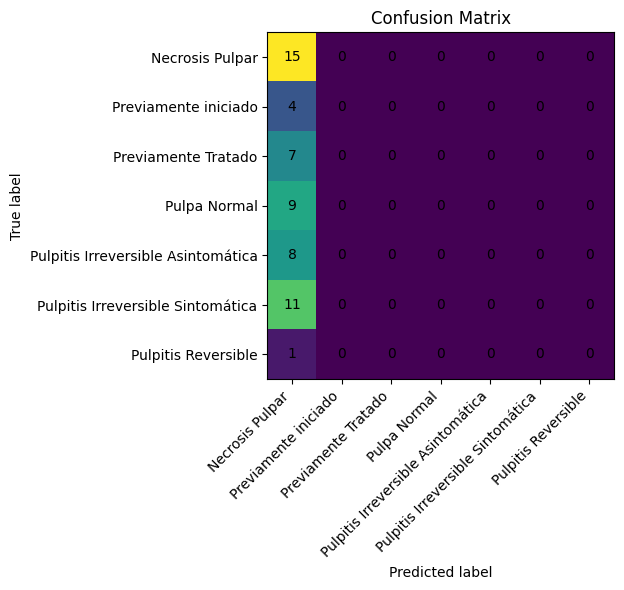

In [32]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)


In [33]:
from collections import Counter

test_loader = data_module["loaders"]["test"]

loader_labels = []

for images, clinical_vectors, labels in test_loader:
    loader_labels.extend(labels.numpy().tolist())

print("Total labels desde test_loader:", len(loader_labels))
print("Distribución desde test_loader:")

for class_idx, count in sorted(Counter(loader_labels).items()):
    print(class_idx, idx_to_class[class_idx], count)

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4189/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Total labels desde test_loader: 55
Distribución desde test_loader:
0 Necrosis Pulpar 15
1 Previamente iniciado 4
2 Previamente Tratado 7
3 Pulpa Normal 9
4 Pulpitis Irreversible Asintomática 8
5 Pulpitis Irreversible Sintomática 11
6 Pulpitis Reversible 1


# Cross validation of the model

In [34]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Subset
import pandas as pd
import numpy as np
import copy
import torch
import torch.nn as nn

K_FOLDS = 5
KFOLD_EPOCHS = 50
KFOLD_BATCH_SIZE = 64
KFOLD_NUM_WORKERS = 0
KFOLD_SEED = 42

In [35]:
def build_fresh_full_model():
 
    extractor = CNNEmbeddingExtractor(model)

    fused_classifier = FusedClassifier(
        num_classes=len(class_to_idx),
    )

    fold_model = FullMultimodalDentalDeppGAModel(
        embedding_extractor=extractor,
        fused_classifier=fused_classifier,
    ).to(device)

    return fold_model


def build_optimizer_for_full_model(fold_model):
   
    optimizer = torch.optim.AdamW([
        {"params": fold_model.embedding_extractor.parameters(), "lr": 1e-6},
        {"params": fold_model.fused_classifier.parameters(), "lr": 3e-4},
    ], weight_decay=5e-4)

    return optimizer


def make_fold_loaders(ds, train_indices, val_indices, batch_size=64, num_workers=0, seed=42):
    g = torch.Generator()
    g.manual_seed(seed)

    pin = torch.backends.mps.is_available()

    train_loader = DataLoader(
        Subset(ds, train_indices),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=num_workers,
        pin_memory=pin,
    )

    val_loader = DataLoader(
        Subset(ds, val_indices),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    return train_loader, val_loader

In [36]:
ds = data_module["dataset"]

train_idx = np.array(data_module["splits"]["train_idx"])
val_idx = np.array(data_module["splits"]["val_idx"])
test_idx = np.array(data_module["splits"]["test_idx"])

# K-Fold SOLO con train + val
kfold_pool_idx = np.concatenate([train_idx, val_idx])
kfold_pool_labels = np.array([ds.targets[i] for i in kfold_pool_idx])

print("Total train original:", len(train_idx))
print("Total val original:", len(val_idx))
print("Total test hold-out:", len(test_idx))
print("Total usado en K-Fold train+val:", len(kfold_pool_idx))

# Validaciones formales
assert len(set(train_idx).intersection(set(test_idx))) == 0
assert len(set(val_idx).intersection(set(test_idx))) == 0
assert len(set(kfold_pool_idx).intersection(set(test_idx))) == 0

print("✅ Sin data leakage: test_idx NO se usa dentro del K-Fold.")

Total train original: 254
Total val original: 55
Total test hold-out: 55
Total usado en K-Fold train+val: 309
✅ Sin data leakage: test_idx NO se usa dentro del K-Fold.


In [37]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

skf = StratifiedKFold(
    n_splits=K_FOLDS,
    shuffle=True,
    random_state=KFOLD_SEED,
)

fold_results = []
fold_histories = []

for fold, (train_pos, val_pos) in enumerate(skf.split(kfold_pool_idx, kfold_pool_labels), start=1):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}/{K_FOLDS}")
    print("=" * 70)

    fold_train_idx = kfold_pool_idx[train_pos]
    fold_val_idx = kfold_pool_idx[val_pos]

    # Seguridad: el test nunca debe aparecer aquí
    assert len(set(fold_train_idx).intersection(set(test_idx))) == 0
    assert len(set(fold_val_idx).intersection(set(test_idx))) == 0
    assert len(set(fold_train_idx).intersection(set(fold_val_idx))) == 0

    print("Train fold:", len(fold_train_idx))
    print("Val fold:", len(fold_val_idx))

    show_split_distribution(ds, fold_train_idx, f"FOLD {fold} TRAIN", idx_to_class)
    show_split_distribution(ds, fold_val_idx, f"FOLD {fold} VAL", idx_to_class)

    fold_train_loader, fold_val_loader = make_fold_loaders(
        ds=ds,
        train_indices=fold_train_idx,
        val_indices=fold_val_idx,
        batch_size=KFOLD_BATCH_SIZE,
        num_workers=KFOLD_NUM_WORKERS,
        seed=KFOLD_SEED + fold,
    )

    fold_model = build_fresh_full_model()

    fold_criterion = nn.CrossEntropyLoss()

    fold_optimizer = build_optimizer_for_full_model(fold_model)

    fold_model, fold_history = train_model(
        model=fold_model,
        train_loader=fold_train_loader,
        val_loader=fold_val_loader,
        criterion=fold_criterion,
        optimizer=fold_optimizer,
        device=device,
        epochs=KFOLD_EPOCHS,
    )

    fold_eval = evaluate_classification_model(
        model=fold_model,
        loader=fold_val_loader,
        device=device,
        idx_to_class=idx_to_class,
    )

    fold_row = {
        "fold": fold,
        "accuracy": fold_eval["accuracy"],
        "precision_macro": fold_eval["precision_macro"],
        "recall_macro": fold_eval["recall_macro"],
        "f1_macro": fold_eval["f1_macro"],
        "precision_weighted": fold_eval["precision_weighted"],
        "recall_weighted": fold_eval["recall_weighted"],
        "f1_weighted": fold_eval["f1_weighted"],
    }

    fold_results.append(fold_row)
    fold_histories.append(fold_history)

    print("\nResultados del fold:")
    for key, value in fold_row.items():
        if key != "fold":
            print(f"{key}: {value:.4f}")

    print("\nClassification report:")
    print(fold_eval["classification_report"])


FOLD 1/5
Train fold: 247
Val fold: 62

FOLD 1 TRAIN total = 247
  Necrosis Pulpar                      68  (27.53%)
  Previamente iniciado                 16  ( 6.48%)
  Previamente Tratado                  29  (11.74%)
  Pulpa Normal                         42  (17.00%)
  Pulpitis Irreversible Asintomática   39  (15.79%)
  Pulpitis Irreversible Sintomática    50  (20.24%)
  Pulpitis Reversible                   3  ( 1.21%)

FOLD 1 VAL total = 62
  Necrosis Pulpar                      17  (27.42%)
  Previamente iniciado                  5  ( 8.06%)
  Previamente Tratado                   7  (11.29%)
  Pulpa Normal                         10  (16.13%)
  Pulpitis Irreversible Asintomática    9  (14.52%)
  Pulpitis Irreversible Sintomática    13  (20.97%)
  Pulpitis Reversible                   1  ( 1.61%)


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4189/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8502 | Train Acc: 0.2348 | Val Loss: 1.8284 | Val Acc: 0.2742
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.2742 | Val Loss: 1.8284
Epoch 02/50 | Train Loss: 1.5595 | Train Acc: 0.3846 | Val Loss: 1.7892 | Val Acc: 0.2097
Epoch 03/50 | Train Loss: 1.2665 | Train Acc: 0.4980 | Val Loss: 1.5398 | Val Acc: 0.3226
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.3226 | Val Loss: 1.5398
Epoch 04/50 | Train Loss: 1.0599 | Train Acc: 0.6275 | Val Loss: 1.4714 | Val Acc: 0.4194
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4194 | Val Loss: 1.4714
Epoch 05/50 | Train Loss: 0.8631 | Train Acc: 0.7490 | Val Loss: 1.3642 | Val Acc: 0.5645
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5645 | Val Loss: 1.3642
Epoch 06/50 | Train Loss: 0.7470 | Train Acc: 0.7611 | Val Loss: 1.3279 | Val Acc: 0.5323
Epoch 07/50 | Train Loss: 0.6377 | Train Acc: 0.7571 | Val Loss: 1.2786 | Val Acc: 0.5323
Epoch 08/50 | Train Loss: 0.5484 | Train Acc: 0.8219 | Val Loss: 1.3463 | Val Acc: 0.5806


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4189/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8539 | Train Acc: 0.2429 | Val Loss: 1.7178 | Val Acc: 0.3710
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.3710 | Val Loss: 1.7178
Epoch 02/50 | Train Loss: 1.5244 | Train Acc: 0.3725 | Val Loss: 1.7340 | Val Acc: 0.2903
Epoch 03/50 | Train Loss: 1.2169 | Train Acc: 0.5709 | Val Loss: 1.6087 | Val Acc: 0.3065
Epoch 04/50 | Train Loss: 0.9557 | Train Acc: 0.6478 | Val Loss: 1.4325 | Val Acc: 0.5484
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.5484 | Val Loss: 1.4325
Epoch 05/50 | Train Loss: 0.8735 | Train Acc: 0.6923 | Val Loss: 1.3180 | Val Acc: 0.5484
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5484 | Val Loss: 1.3180
Epoch 06/50 | Train Loss: 0.6942 | Train Acc: 0.7652 | Val Loss: 1.2042 | Val Acc: 0.6129
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.6129 | Val Loss: 1.2042
Epoch 07/50 | Train Loss: 0.5350 | Train Acc: 0.8543 | Val Loss: 1.1678 | Val Acc: 0.6129
  ✅ Nuevo mejor modelo | Epoch 7 | Val Acc: 0.6129 | Val Loss: 1.1678
Epoch 08/50 | Train 

...

Epoch 01/50 | Train Loss: 1.8275 | Train Acc: 0.2186 | Val Loss: 2.0328 | Val Acc: 0.1613
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.1613 | Val Loss: 2.0328
Epoch 02/50 | Train Loss: 1.3696 | Train Acc: 0.4818 | Val Loss: 1.6744 | Val Acc: 0.3065
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3065 | Val Loss: 1.6744
Epoch 03/50 | Train Loss: 1.1181 | Train Acc: 0.5911 | Val Loss: 1.4252 | Val Acc: 0.5323
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.5323 | Val Loss: 1.4252
Epoch 04/50 | Train Loss: 0.8733 | Train Acc: 0.7287 | Val Loss: 1.2773 | Val Acc: 0.5968
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.5968 | Val Loss: 1.2773
Epoch 05/50 | Train Loss: 0.7230 | Train Acc: 0.7045 | Val Loss: 1.1032 | Val Acc: 0.6452
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.6452 | Val Loss: 1.1032
Epoch 06/50 | Train Loss: 0.5841 | Train Acc: 0.7935 | Val Loss: 1.1425 | Val Acc: 0.5968
Epoch 07/50 | Train Loss: 0.4809 | Train Acc: 0.8583 | Val Loss: 1.0107 | Val Acc: 0.6774
  ✅ Nuevo mejor mode

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4189/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8550 | Train Acc: 0.2713 | Val Loss: 1.9966 | Val Acc: 0.2097
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.2097 | Val Loss: 1.9966
Epoch 02/50 | Train Loss: 1.5384 | Train Acc: 0.4251 | Val Loss: 1.7386 | Val Acc: 0.3065
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3065 | Val Loss: 1.7386
Epoch 03/50 | Train Loss: 1.2966 | Train Acc: 0.5142 | Val Loss: 1.7334 | Val Acc: 0.3387
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.3387 | Val Loss: 1.7334
Epoch 04/50 | Train Loss: 1.0252 | Train Acc: 0.6275 | Val Loss: 1.3072 | Val Acc: 0.4839
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4839 | Val Loss: 1.3072
Epoch 05/50 | Train Loss: 0.8484 | Train Acc: 0.6721 | Val Loss: 1.2419 | Val Acc: 0.5645
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5645 | Val Loss: 1.2419
Epoch 06/50 | Train Loss: 0.7334 | Train Acc: 0.7409 | Val Loss: 1.0614 | Val Acc: 0.5323
Epoch 07/50 | Train Loss: 0.6273 | Train Acc: 0.7814 | Val Loss: 0.9270 | Val Acc: 0.6452
  ✅ Nuevo mejor mode

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4189/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8703 | Train Acc: 0.2379 | Val Loss: 1.7858 | Val Acc: 0.1967
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.1967 | Val Loss: 1.7858
Epoch 02/50 | Train Loss: 1.4768 | Train Acc: 0.4274 | Val Loss: 1.5271 | Val Acc: 0.3443
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3443 | Val Loss: 1.5271
Epoch 03/50 | Train Loss: 1.2033 | Train Acc: 0.5685 | Val Loss: 1.4440 | Val Acc: 0.4262
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.4262 | Val Loss: 1.4440
Epoch 04/50 | Train Loss: 0.9593 | Train Acc: 0.6895 | Val Loss: 1.2486 | Val Acc: 0.4918
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4918 | Val Loss: 1.2486
Epoch 05/50 | Train Loss: 0.7722 | Train Acc: 0.7621 | Val Loss: 1.2249 | Val Acc: 0.5574
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5574 | Val Loss: 1.2249
Epoch 06/50 | Train Loss: 0.6115 | Train Acc: 0.7984 | Val Loss: 1.1823 | Val Acc: 0.5574
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.5574 | Val Loss: 1.1823
Epoch 07/50 | Train Loss: 0.5108 | Train

In [38]:
kfold_results_df = pd.DataFrame(fold_results)

display(kfold_results_df)

metrics = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
]

summary_rows = []

for metric in metrics:
    values = kfold_results_df[metric].values

    summary_rows.append({
        "metric": metric,
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "min": np.min(values),
        "max": np.max(values),
    })

kfold_summary_df = pd.DataFrame(summary_rows)

display(kfold_summary_df)

print("\n" + "=" * 70)
print("RESULTADOS FINALES STRATIFIED K-FOLD")
print("=" * 70)

for _, row in kfold_summary_df.iterrows():
    print(
        f"{row['metric']:<20}: "
        f"{row['mean']:.4f} ± {row['std']:.4f} "
        f"(min={row['min']:.4f}, max={row['max']:.4f})"
    )

,fold,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,1,0.612903,0.466558,0.471201,0.457533,0.592265,0.612903,0.589356
1,2,0.677419,0.499452,0.555074,0.523249,0.632110,0.677419,0.650792
2,3,0.677419,0.544905,0.487986,0.484354,0.670395,0.677419,0.639324
3,4,0.758065,0.665685,0.670947,0.667607,0.751523,0.758065,0.753917
4,5,0.672131,0.726190,0.633851,0.636383,0.703877,0.672131,0.667229


,metric,mean,std,min,max
0,accuracy,0.679588,0.051649,0.612903,0.758065
1,precision_macro,0.580558,0.111019,0.466558,0.726190
2,recall_macro,0.563812,0.087730,0.471201,0.670947
3,f1_macro,0.553825,0.093268,0.457533,0.667607
4,precision_weighted,0.670034,0.061790,0.592265,0.751523
5,recall_weighted,0.679588,0.051649,0.612903,0.758065
6,f1_weighted,0.660123,0.059949,0.589356,0.753917



RESULTADOS FINALES STRATIFIED K-FOLD
accuracy            : 0.6796 ± 0.0516 (min=0.6129, max=0.7581)
precision_macro     : 0.5806 ± 0.1110 (min=0.4666, max=0.7262)
recall_macro        : 0.5638 ± 0.0877 (min=0.4712, max=0.6709)
f1_macro            : 0.5538 ± 0.0933 (min=0.4575, max=0.6676)
precision_weighted  : 0.6700 ± 0.0618 (min=0.5923, max=0.7515)
recall_weighted     : 0.6796 ± 0.0516 (min=0.6129, max=0.7581)
f1_weighted         : 0.6601 ± 0.0599 (min=0.5894, max=0.7539)


In [39]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

results = evaluate_classification_model(
   #model=train_full_model,
    model=fold_model,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print(f"Accuracy           : {results['accuracy']:.4f}")
print(f"Precision macro    : {results['precision_macro']:.4f}")
print(f"Recall macro       : {results['recall_macro']:.4f}")
print(f"F1 macro           : {results['f1_macro']:.4f}")
print(f"Precision weighted : {results['precision_weighted']:.4f}")
print(f"Recall weighted    : {results['recall_weighted']:.4f}")
print(f"F1 weighted        : {results['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results["classification_report"])

print("Confusion matrix:\n")
print(results["confusion_matrix"])

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4189/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Accuracy           : 0.5818
Precision macro    : 0.4459
Recall macro       : 0.4653
F1 macro           : 0.4411
Precision weighted : 0.5568
Recall weighted    : 0.5818
F1 weighted        : 0.5552

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.57      0.53      0.55        15
              Previamente iniciado       0.00      0.00      0.00         4
               Previamente Tratado       0.75      0.43      0.55         7
                      Pulpa Normal       0.90      1.00      0.95         9
Pulpitis Irreversible Asintomática       0.40      0.75      0.52         8
 Pulpitis Irreversible Sintomática       0.50      0.55      0.52        11
               Pulpitis Reversible       0.00      0.00      0.00         1

                          accuracy                           0.58        55
                         macro avg       0.45      0.47      0.44        55
                 

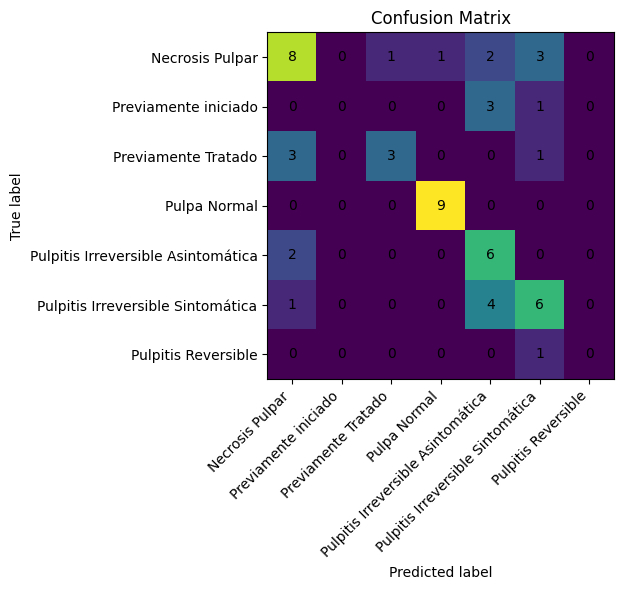

In [40]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)
